# RQ-001 — Regime Durability

Executed 2026-09-22. v0, provisional. Ten fixed sections; imports
`loci.model.regime_durability` for all logic — this notebook is the executed
report, not where the math lives.


## 0. Question

**As asked:** "How often does the landscape of a neighborhood fully shift — what
causes it? If a restaurant were to purchase a storefront in a neighborhood, how
long should they anticipate for the favorable conditions to last? This should
take into account neighborhood information, foot traffic change over time,
favorable macroeconomic conditions (if that's a true factor)."

**What this run answers:** a ZIP-tier (unit = frozen postal ZIP / ZCTA), 2000-2023
base rate for how long a unit stays in the top ~third of a demand/supply/cost
relative-rank composite — **not** an absolute measure of "good conditions" — plus
ranked drivers of exit and a macro association test. Full method:
`docs/research/RQ-001-regime-durability/METHOD.md`. This run implements the v0
recipe **as amended** by the contrarian and statistician verdicts at the bottom
of that file, **further amended by owner rulings dated 2026-09-22**:

> - **"Run both, compare"**: compute (A) the ORIGINAL equal-weight composite
>   (demand/supply/cost) AND (B) the AMENDED definition (demand ≥ median gate;
>   saturation = restaurants per $ of local spending; OWNER composite without
>   cost; TENANT composite with 3-yr cost-rank rise). Report durations for A,
>   B-owner, B-tenant side by side and the sensitivity.
> - **"Median anyway, flagged"**: if <60 completed incident spells, STILL report
>   the KM median with its wide CI and an explicit LOW-SAMPLE flag, alongside
>   the hazard-by-spell-age table.
> - Also run the threshold-rule vs regime-model (k-means k=4 + Markov)
>   comparison per the seed.

**Documented deviations from METHOD.md**, made necessary by what is actually in
this warehouse (see `regime_durability.py`'s module docstring for the full
list): the headline window is **2000-2023** (not 1994-99 pre-window — ZBP here
starts 1998, population starts at the 2000 census, so there is no earlier
2-pillar dating panel); ZIP is treated as ZCTA (no USPS crosswalk file in this
repo); only the spatial-block bootstrap runs (no PUMA crosswalk found).


## 1. Data & provenance

Every loader in `regime_durability.py` prints which source it used and its
coverage — that print output IS the provenance record; it is not duplicated by
hand here. The warehouse is opened read-only with a 10-minute retry/backoff (a
peer session may hold the write lock), printing a heartbeat every 15s.

In [1]:
import sys, time, pathlib
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path.cwd() / "src"))
from loci.model import regime_durability as rd

DB_PATH = pathlib.Path("data/loci.duckdb")

def connect_with_backoff(path=DB_PATH, timeout_s=600, poll_s=15):
    deadline = time.time() + timeout_s
    attempt = 0
    while time.time() < deadline:
        attempt += 1
        try:
            con = duckdb.connect(str(path), read_only=True)
            print(f"[warehouse] unlocked after {attempt} attempt(s)")
            return con
        except Exception as exc:
            print(f"[warehouse] heartbeat attempt={attempt}: still locked ({exc.__class__.__name__})", flush=True)
            time.sleep(poll_s)
    raise RuntimeError(f"warehouse still locked after {timeout_s}s — BLOCKED")

con = connect_with_backoff()
print("connected read_only:", con is not None)


[warehouse] unlocked after 1 attempt(s)
connected read_only: True


In [2]:
# Build the full panel — this call chains every loader (supply, ZHVI, ZORI,
# population, workers/LODES, income (IRS SOI or ACS fallback), macro, geometry)
# and prints each source's provenance line.
panel, provenance = rd.build_zip_year_panel(con)
print()
print("=== provenance summary ===")
for k, v in provenance.items():
    if k == "zori_zhvi_rank_corr_by_year":
        continue
    print(f"{k}: {v}")
print(f"n_units={panel['unit'].nunique()}  years={panel['year'].min()}-{panel['year'].max()}  rows={len(panel)}")
zori_corr = pd.Series(provenance["zori_zhvi_rank_corr_by_year"])
print()
print("ZORI vs ZHVI rank correlation by year (check only, not a composite input):")
print(zori_corr.describe())


[loader] supply: analysis.zip_establishments, 1998-2023, 208 units
[loader] cost (ZHVI): data/interim/rq001/zillow/zillow_nyc_annual.parquet, 2000-2026, 169 units
[loader] cost check (ZORI): data/interim/rq001/zillow/zillow_nyc_annual.parquet, 2015-2026, 145 units (check only, not a composite input)


[loader] population: data/interim/rq002/decennial/zcta_pop_interpolated_2000_2020.parquet, interpolated 2000-2020, carried forward flat 2021-2023 (35551 units)
[loader] workers: data/interim/rq001/lodes/lodes_wac_zcta.parquet, LODES C000 2002-2023, 1998-2001 back-filled flat from 2002 (211 units)


[loader] income: data/interim/rq001/irs_soi/irs_zip_income_panel.parquet (IRS SOI mean AGI/return, total row only), published tax years [np.int64(1998), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], 4161 published unit-years, 831 interpolated/carried-forward unit-years, 208 units
[loader] macro: data/interim/rq001/macro/macro_annual.parquet, series ['CES7072200001', 'CUSR0000SEFV', 'CUURA101SA0', 'FEDFUNDS', 'GS10', 'MORTGAGE30US', 'NEWY636URN', 'NYUR', 'SMU36935617072200001', 'UNRATE', 'USREC'], 1854-2026
[loader] ZCTA geometry (2020 vintage, static across the panel): data/interim/rq002/zcta_boundaries/zcta_2020_nyc.parquet, 205 units


[panel] frozen universe: 150 units, 2000-2023



=== provenance summary ===
n_units: 150
years: (2000, 2023)
income_source: irs_soi
n_units=150  years=2000-2023  rows=3600

ZORI vs ZHVI rank correlation by year (check only, not a composite input):
count    9.000000
mean     0.768440
std      0.025377
min      0.731691
25%      0.746403
50%      0.774802
75%      0.788298
max      0.808042
dtype: float64


## 2. Build panel

The panel is on the **frozen unit universe** (METHOD §1: population >= 2,000 in
every headline year, present in supply and ZHVI every headline year, merged
splits per statistician S1: 11249->11211, 10065/10075->10021, 11109->11101).
Pillar percentiles and all four composites (ORIGINAL A, AMENDED owner, AMENDED
tenant, plus the raw components needed for the regime model) are computed here
once and reused by every section below.

In [3]:
df = rd.compute_pillar_percentiles(panel)
print(df.shape, "rows x", df.shape[1], "columns")
print()
print("composite summary stats:")
print(df[["composite_A", "composite_B_owner", "composite_B_tenant"]].describe())
print()
gate_by_year = df.groupby("year")["demand_gate"].mean()
print(f"demand-gate pass rate (share of unit-years eligible for the AMENDED composites), "
      f"overall: {df['demand_gate'].mean():.1%}")
print("=== GTM-230 item 2: demand-gate pass rate BY YEAR (must be free to vary, not pinned "
      "at ~50% every year -- that was the bug) ===")
print(gate_by_year.to_string(float_format=lambda v: f"{v:.1%}"))
print(f"min={gate_by_year.min():.1%}  max={gate_by_year.max():.1%}  "
      f"range={gate_by_year.max()-gate_by_year.min():.1%}  std={gate_by_year.std():.1%}")


(3600, 47) rows x 47 columns

composite summary stats:
       composite_A  composite_B_owner  composite_B_tenant
count  3600.000000        3600.000000         3150.000000
mean      0.503333           0.255724            0.258415
std       0.288698           0.393157            0.393755
min       0.006667           0.000000            0.000000
25%       0.253333           0.000000            0.000000
50%       0.503333           0.000000            0.000000
75%       0.753333           0.753333            0.753333
max       1.000000           1.000000            1.000000

demand-gate pass rate (share of unit-years eligible for the AMENDED composites), overall: 30.1%
=== GTM-230 item 2: demand-gate pass rate BY YEAR (must be free to vary, not pinned at ~50% every year -- that was the bug) ===
year
2000   27.3%
2001   27.3%
2002   27.3%
2003   27.3%
2004   27.3%
2005   27.3%
2006   27.3%
2007   26.7%
2008   27.3%
2009   26.7%
2010   26.7%
2011   26.7%
2012   26.0%
2013   27.3%
2014   28.7

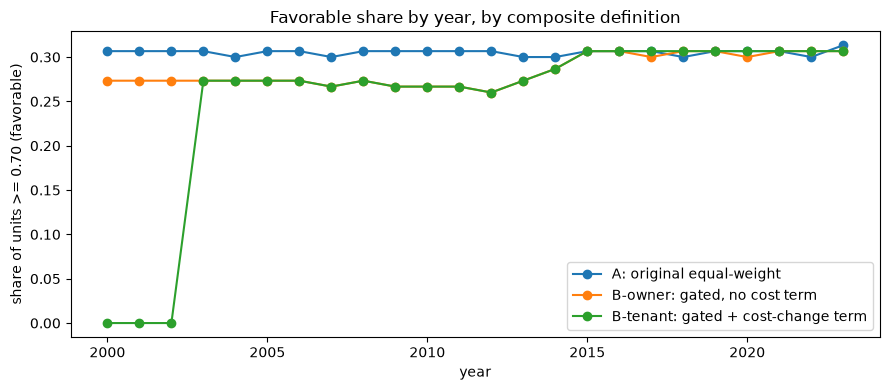

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for col, label in [("composite_A", "A: original equal-weight"),
                    ("composite_B_owner", "B-owner: gated, no cost term"),
                    ("composite_B_tenant", "B-tenant: gated + cost-change term")]:
    favorable_share = df.groupby("year")[col].apply(lambda s: (s >= rd.ENTER_THRESH).mean())
    ax.plot(favorable_share.index, favorable_share.values, marker="o", label=label)
ax.set_ylabel("share of units >= 0.70 (favorable)")
ax.set_xlabel("year")
ax.set_title("Favorable share by year, by composite definition")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Method

**Spell detection**: METHOD §2 hysteresis — enter at composite >= 0.70 for 2
consecutive years (onset = first of those years), exit at composite < 0.60 for
2 consecutive years (exit year = first of those years); minimum spell length 2
years. Applied independently to composite A, B-owner and B-tenant.

**Two "full shift" definitions run and compared** (SEED.yaml constraint): (i)
the threshold/hysteresis rule above, and (ii) a data-driven k-means (k=4) +
Markov regime model fit on data <=2013 (section 6).

In [5]:
spells_A = rd.hysteresis_spells(df, "composite_A")
spells_Bo = rd.hysteresis_spells(df, "composite_B_owner")
spells_Bt = rd.hysteresis_spells(df, "composite_B_tenant")

for name, sp in [("A (original)", spells_A), ("B-owner", spells_Bo), ("B-tenant", spells_Bt)]:
    inc = sp[sp["incident"]] if len(sp) else sp
    prev = sp[~sp["incident"]] if len(sp) else sp
    n_completed = int((~inc["censored"]).sum()) if len(inc) else 0
    print(f"{name:14s}  spells={len(sp):3d}  incident={len(inc):3d}  "
          f"completed_incident={n_completed:3d}  prevalent(2000)={len(prev):3d}  "
          f"distinct_units={inc['unit'].nunique() if len(inc) else 0}")


A (original)    spells= 72  incident=  3  completed_incident=  1  prevalent(2000)= 69  distinct_units=3
B-owner         spells= 55  incident= 13  completed_incident=  0  prevalent(2000)= 42  distinct_units=13
B-tenant        spells= 52  incident= 11  completed_incident=  0  prevalent(2000)= 41  distinct_units=11


## 4. Results

Owner ruling: report the incident-spell KM median **even below the 60-completed-
exit bar**, flagged LOW-SAMPLE, alongside the hazard-by-spell-age table (which
does not depend on hitting a median and is the more honest object at this
sample size).

In [6]:
km_results = {}
for name, sp in [("A", spells_A), ("B_owner", spells_Bo), ("B_tenant", spells_Bt)]:
    km_results[name] = rd.km_summary(sp, low_sample_bar=60)

print("NOTE: at this sample size the KM curve routinely never crosses 0.5 (heavy "
      "censoring), which makes the median mathematically infinite/undefined, not just "
      "imprecise. RMST (restricted mean survival time, truncated per statistician S6 at "
      "the largest spell-age with >=10 units still at risk, capped at 20y) is reported "
      "alongside and is the estimable point figure.")
print()
print(f"{'composite':10s} {'n_incident':>10s} {'completed':>10s} {'units':>6s} {'median':>8s} {'RMST':>7s} {'trunc':>6s} {'LOW_SAMPLE':>10s}")
for name, r in km_results.items():
    med = r["median"]
    med_s = f"{med:.1f}" if np.isfinite(med) else "inf/undefined"
    rmst_s = f"{r['rmst']:.2f}" if np.isfinite(r.get('rmst', np.nan)) else "na"
    print(f"{name:10s} {r['n_incident_spells']:10d} {r['n_completed']:10d} {r['n_distinct_units']:6d} "
          f"{med_s:>8s} {rmst_s:>7s} {r.get('rmst_trunc', float('nan')):>6.0f} {str(r['low_sample_flag']):>10s}")


NOTE: at this sample size the KM curve routinely never crosses 0.5 (heavy censoring), which makes the median mathematically infinite/undefined, not just imprecise. RMST (restricted mean survival time, truncated per statistician S6 at the largest spell-age with >=10 units still at risk, capped at 20y) is reported alongside and is the estimable point figure.

composite  n_incident  completed  units   median    RMST  trunc LOW_SAMPLE
A                   3          1      3      6.0    6.00      6       True
B_owner            13          0     13 inf/undefined    3.00      3       True
B_tenant           11          0     11 inf/undefined    2.00      2       True


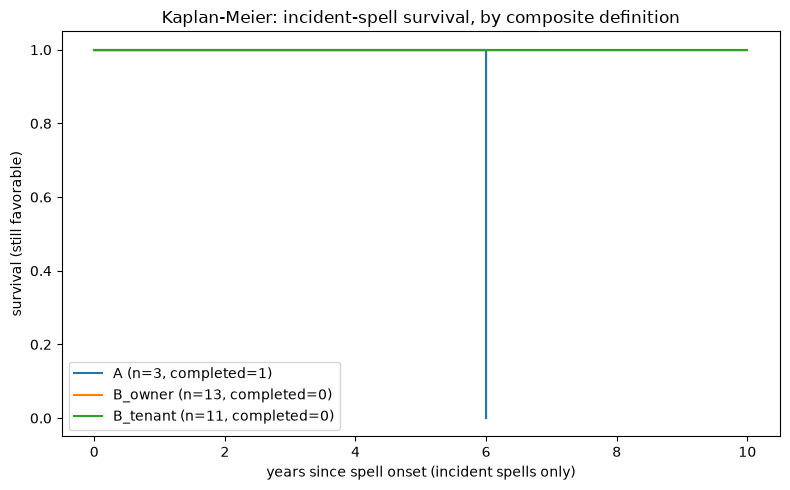

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, r in km_results.items():
    if "kmf" in r:
        r["kmf"].plot_survival_function(ax=ax, label=f"{name} (n={r['n_incident_spells']}, completed={r['n_completed']})")
ax.set_xlabel("years since spell onset (incident spells only)")
ax.set_ylabel("survival (still favorable)")
ax.set_title("Kaplan-Meier: incident-spell survival, by composite definition")
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
print("=== Hazard by spell-age band (pools incident + prevalent(2000) spell-years) — "
      "the ANNUAL EXIT HAZARD, the fallback/S6 headline when the completed-exit count gate fails "
      "(it does, for all three composites here). Cluster-robust (unit-block bootstrap) CI included, "
      "per the parent task instruction to report this as the fallback headline with a CI. ===")
hazard_results = {}
for name, sp in [("A", spells_A), ("B_owner", spells_Bo), ("B_tenant", spells_Bt)]:
    print(f"\n--- {name} ---")
    hz = rd.hazard_by_spell_age_ci(sp, reps=1000, seed=42)
    hazard_results[name] = hz
    print(hz.to_string(index=False))


=== Hazard by spell-age band (pools incident + prevalent(2000) spell-years) — the ANNUAL EXIT HAZARD, the fallback/S6 headline when the completed-exit count gate fails (it does, for all three composites here). Cluster-robust (unit-block bootstrap) CI included, per the parent task instruction to report this as the fallback headline with a CI. ===

--- A ---


           age_band  n_spells  n_events  spell_years   hazard  n_boot_valid  hazard_ci_lower  hazard_ci_upper
unknown (prevalent)        69        18         1166 0.015437          1000         0.009359         0.022969
                0-5         3         1           14 0.071429           943         0.000000         0.166667
               6-10         0         0            0      NaN             0              NaN              NaN
             11-100         0         0            0      NaN             0              NaN              NaN

--- B_owner ---


           age_band  n_spells  n_events  spell_years   hazard  n_boot_valid  hazard_ci_lower  hazard_ci_upper
unknown (prevalent)        42         1          933 0.001072          1000              0.0         0.003572
                0-5        13         0           62 0.000000          1000              0.0         0.000000
               6-10         8         0           19 0.000000           999              0.0         0.000000
             11-100         0         0            0      NaN             0              NaN              NaN

--- B_tenant ---


           age_band  n_spells  n_events  spell_years   hazard  n_boot_valid  hazard_ci_lower  hazard_ci_upper
unknown (prevalent)        41         1          806 0.001241          1000              0.0         0.004428
                0-5        11         0           53 0.000000          1000              0.0         0.000000
               6-10         7         0           17 0.000000          1000              0.0         0.000000
             11-100         0         0            0      NaN             0              NaN              NaN


In [9]:
print("=== Stock-flow sanity check (METHOD §3) ===")
for name, sp in [("A", spells_A), ("B_owner", spells_Bo), ("B_tenant", spells_Bt)]:
    sf = rd.stock_flow_check(df, sp, {"A": "composite_A", "B_owner": "composite_B_owner", "B_tenant": "composite_B_tenant"}[name])
    print(f"{name:10s} mean_stock={sf['mean_stock']:.1f}  exits/yr={sf['exits_per_year']:.2f}  "
          f"implied_mean_duration={sf['implied_mean_duration']:.1f}")


=== Stock-flow sanity check (METHOD §3) ===
A          mean_stock=45.8  exits/yr=0.79  implied_mean_duration=57.8
B_owner    mean_stock=42.6  exits/yr=0.04  implied_mean_duration=1023.0
B_tenant   mean_stock=37.6  exits/yr=0.04  implied_mean_duration=902.0


## 5. Sensitivity

METHOD §2 grid (band x persistence). If the median moves by more than 50%
across the grid, the answer is the grid, not a single number. Break-year
detection (statistician S5, a robust leave-one-out outlier test on the
year-over-year rank shuffle — NOT a literal "exceeds the max of the other
years", which by construction cannot flag a break that itself falls in a
non-candidate year) flags any measurement-break candidates. The rank-churn
null (contrarian amendment 5) asks whether the observed median is
indistinguishable from pure rank persistence with no regime structure. The
spatial-block bootstrap gives the CI (no PUMA crosswalk was found in this
repo, so it is the only CI reported — a documented gap, not a silent
substitution).

In [10]:
print("=== Sensitivity grid: composite A ===")
grid_A = rd.sensitivity_grid(df, "composite_A")
print(grid_A.to_string(index=False))
head_median_A = grid_A[(grid_A.exit_thresh == 0.60) & (grid_A.enter_thresh == 0.70) & (grid_A.persist == 2)]["median"].iloc[0]
if np.isfinite(head_median_A) and head_median_A > 0:
    grid_A["pct_move_from_headline"] = (grid_A["median"] / head_median_A - 1).abs()
    max_move_A = grid_A["pct_move_from_headline"].max()
    print(f"\nheadline median (0.60/0.70, persist=2): {head_median_A:.1f}; max grid move: {max_move_A:.1%} "
          f"({'>50% -> GRID IS THE ANSWER' if max_move_A > 0.5 else 'within 50%'})")
else:
    print("\nheadline median is inf/undefined (KM never crosses 0.5) -- the grid itself is the answer, not a single number.")


=== Sensitivity grid: composite A ===


 exit_thresh  enter_thresh  persist  n_incident_spells  n_completed  median
       0.667         0.667        1                 78           44     6.0
       0.667         0.667        2                 42           16    18.0
       0.667         0.667        3                 32           10     inf
       0.630         0.700        1                 17            8     6.0
       0.630         0.700        2                  8            2     inf
       0.630         0.700        3                  5            1     inf
       0.600         0.700        1                  5            2     6.0
       0.600         0.700        2                  3            1     6.0
       0.600         0.700        3                  1            1     6.0
       0.570         0.730        1                  1            1     6.0
       0.570         0.730        2                  1            1     6.0
       0.570         0.730        3                  1            1     6.0

headline me

In [11]:
print("=== Sensitivity grid: composite B_tenant (statistician post-results condition 4 / "
      "explicit instruction: run the grid for B-tenant too, not just A) ===")
grid_Bt = rd.sensitivity_grid(df, "composite_B_tenant")
print(grid_Bt.to_string(index=False))
head_row_Bt = grid_Bt[(grid_Bt.exit_thresh == 0.60) & (grid_Bt.enter_thresh == 0.70) & (grid_Bt.persist == 2)]
head_median_Bt = head_row_Bt["median"].iloc[0] if len(head_row_Bt) else np.nan
if np.isfinite(head_median_Bt) and head_median_Bt > 0:
    grid_Bt["pct_move_from_headline"] = (grid_Bt["median"] / head_median_Bt - 1).abs()
    max_move_Bt = grid_Bt["pct_move_from_headline"].max()
    print(f"\nheadline median (0.60/0.70, persist=2): {head_median_Bt:.1f}; max grid move: {max_move_Bt:.1%} "
          f"({'>50% -> GRID IS THE ANSWER' if max_move_Bt > 0.5 else 'within 50%'})")
else:
    print("\nheadline median is inf/undefined (KM never crosses 0.5) -- the grid itself is the answer, not a single number.")


=== Sensitivity grid: composite B_tenant (statistician post-results condition 4 / explicit instruction: run the grid for B-tenant too, not just A) ===


 exit_thresh  enter_thresh  persist  n_incident_spells  n_completed  median
       0.667         0.667        1                 27            5     inf
       0.667         0.667        2                 19            4     inf
       0.667         0.667        3                 13            1     inf
       0.630         0.700        1                 17            2     inf
       0.630         0.700        2                 11            0     inf
       0.630         0.700        3                 10            0     inf
       0.600         0.700        1                 17            1     inf
       0.600         0.700        2                 11            0     inf
       0.600         0.700        3                 10            0     inf
       0.570         0.730        1                 13            1     inf
       0.570         0.730        2                  9            0     inf
       0.570         0.730        3                  7            0     inf

headline me

In [12]:
print("=== Break-year detection (composite A) ===")
breaks_A = rd.break_year_rank_shuffle(df, "composite_A")
print(breaks_A.to_string(index=False))
flagged_years = breaks_A[breaks_A["flagged"]]["year"].tolist()
print(f"\nflagged years: {flagged_years}")


=== Break-year detection (composite A) ===
 year  shuffle  n_units  is_candidate_year  flagged
 2001 0.012456      150              False    False
 2002 0.023127      150              False    False
 2003 0.021308      150              False    False
 2004 0.013663      150              False    False
 2005 0.010964      150              False    False
 2006 0.009107      150              False    False
 2007 0.023695      150               True    False
 2008 0.016550      150              False    False
 2009 0.023006      150              False    False
 2010 0.019057      150              False    False
 2011 0.015638      150               True    False
 2012 0.012650      150               True    False
 2013 0.012215      150              False    False
 2014 0.012790      150              False    False
 2015 0.015885      150              False    False
 2016 0.007955      150              False    False
 2017 0.019376      150              False    False
 2018 0.010320      1

In [13]:
print("=== Break-year detection (composite B_tenant) ===")
breaks_Bt = rd.break_year_rank_shuffle(df, "composite_B_tenant")
print(breaks_Bt.to_string(index=False))
flagged_years_Bt = breaks_Bt[breaks_Bt["flagged"]]["year"].tolist()
print(f"\nflagged years: {flagged_years_Bt}")


=== Break-year detection (composite B_tenant) ===
 year  shuffle  n_units  is_candidate_year  flagged
 2001      NaN        0              False    False
 2002      NaN        0              False    False
 2003      NaN        0              False    False
 2004 0.003783      150              False    False
 2005 0.002976      150              False    False
 2006 0.000961      150              False    False
 2007 0.013520      150               True    False
 2008 0.010295      150              False    False
 2009 0.012459      150              False    False
 2010 0.002824      150              False    False
 2011 0.003184      150               True    False
 2012 0.014608      150               True    False
 2013 0.028575      150              False    False
 2014 0.021026      150              False    False
 2015 0.048311      150              False    False
 2016 0.008952      150              False    False
 2017 0.009034      150              False    False
 2018 0.023471

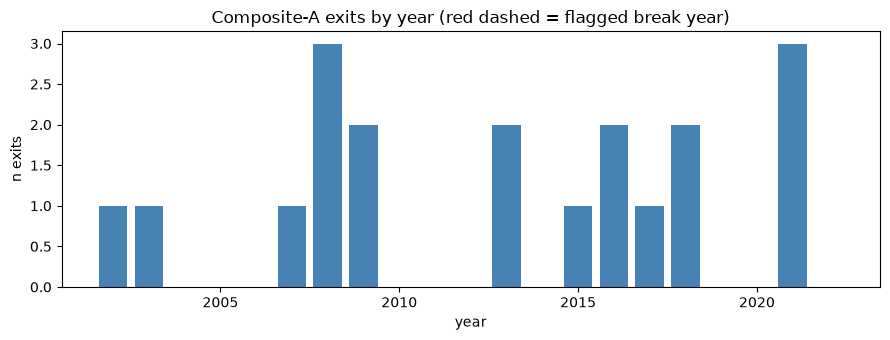

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.5))
exits_by_year = spells_A[~spells_A["censored"]].groupby("exit_year").size()
full_years = pd.Series(0, index=range(2002, 2023))
exits_by_year = (full_years + exits_by_year).fillna(full_years)
ax.bar(exits_by_year.index, exits_by_year.values, color="steelblue")
for y in flagged_years:
    ax.axvline(y, color="red", linestyle="--", alpha=0.6)
ax.set_title("Composite-A exits by year (red dashed = flagged break year)")
ax.set_xlabel("year"); ax.set_ylabel("n exits")
plt.tight_layout()
plt.show()


In [15]:
print("=== Rank-churn null (contrarian amendment 5) — composite A ===")
print("Simulating each unit's composite as an AR(1) in percentile space, re-ranked every year "
      "(preserving the zero-sum tercile constraint), 200 sims (reduced from 1,000 for runtime). "
      "Compared on RMST, not the median -- the median is undefined in most individual sims at "
      "this panel length (24 years), same reason the observed KM median is undefined; see "
      "km_summary's docstring.")
obs_rmst_trunc = km_results["A"]["rmst_trunc"]
null_A = rd.rank_churn_null(df, "composite_A", n_sims=200, seed=7, rmst_trunc=obs_rmst_trunc)
print(f"n_valid_sims(rmst)={null_A['n_valid_sims']}  n_valid_sims(median)={null_A['n_valid_sims_median']}")
print(f"null RMST 95% band=[{null_A['null_rmst_p2_5']:.2f}, {null_A['null_rmst_p97_5']:.2f}] (trunc={obs_rmst_trunc:.0f}y)")
obs_rmst_A = km_results["A"]["rmst"]
inside_band = (null_A["n_valid_sims"] > 0 and np.isfinite(obs_rmst_A)
               and null_A["null_rmst_p2_5"] <= obs_rmst_A <= null_A["null_rmst_p97_5"])
print(f"observed RMST A = {obs_rmst_A:.2f}" if np.isfinite(obs_rmst_A) else "observed RMST A = na")
print(f"observed RMST inside the null band: {inside_band}  "
      f"{'-> HEADLINE WITHHELD (indistinguishable from rank persistence)' if inside_band else '-> observed RMST is outside pure rank-churn noise'}")


=== Rank-churn null (contrarian amendment 5) — composite A ===
Simulating each unit's composite as an AR(1) in percentile space, re-ranked every year (preserving the zero-sum tercile constraint), 200 sims (reduced from 1,000 for runtime). Compared on RMST, not the median -- the median is undefined in most individual sims at this panel length (24 years), same reason the observed KM median is undefined; see km_summary's docstring.


n_valid_sims(rmst)=15  n_valid_sims(median)=15
null RMST 95% band=[3.87, 6.00] (trunc=6y)
observed RMST A = 6.00
observed RMST inside the null band: True  -> HEADLINE WITHHELD (indistinguishable from rank persistence)


In [16]:
print("=== Rank-churn null — composite B_tenant, TWO-PART AR(1) (GTM-230 item 1 / "
      "statistician correction 13) ===")
print("The single-Gaussian-AR(1) null (rank_churn_null) got 0/200 valid sims against "
      "composite_B_tenant in v0.1 -- it mis-fits the point-mass-at-zero mixture created by "
      "the demand gate. This instead fits SEPARATE empirical AR(1)s to the gate/level series "
      "(composite_B_owner) and the cost-rank-change series (tenant_cost_component), combines "
      "them exactly as the real tenant composite does, and applies the identical hysteresis + "
      "strict incident-dating rule.")
obs_rmst_trunc_Bt = km_results["B_tenant"]["rmst_trunc"]
null_Bt = rd.rank_churn_null_tenant_two_part(df, n_sims=200, seed=7,
                                              rmst_trunc=obs_rmst_trunc_Bt if np.isfinite(obs_rmst_trunc_Bt) else 20.0)
print("ok:", null_Bt.get("ok"), null_Bt.get("reason", ""))
if null_Bt.get("ok"):
    print(f"window={null_Bt['window']}  n_units={null_Bt['n_units']}  "
          f"n_valid_spell_sims={null_Bt['n_valid_spell_sims']}")
    print(f"n_valid_sims(rmst)={null_Bt['n_valid_sims']}  n_valid_sims(median)={null_Bt['n_valid_sims_median']}")
    if null_Bt["n_valid_sims"] > 0:
        print(f"null RMST 95% band=[{null_Bt['null_rmst_p2_5']:.2f}, {null_Bt['null_rmst_p97_5']:.2f}] "
              f"(trunc={obs_rmst_trunc_Bt:.0f}y)")
        obs_rmst_Bt = km_results["B_tenant"]["rmst"]
        inside_band_Bt = (np.isfinite(obs_rmst_Bt)
                           and null_Bt["null_rmst_p2_5"] <= obs_rmst_Bt <= null_Bt["null_rmst_p97_5"])
        print(f"observed RMST B_tenant = {obs_rmst_Bt:.2f}" if np.isfinite(obs_rmst_Bt) else "observed RMST B_tenant = na")
        print(f"observed RMST inside the null band: {inside_band_Bt}  "
              f"{'-> HEADLINE WITHHELD (indistinguishable from rank persistence)' if inside_band_Bt else '-> observed RMST is outside pure rank-churn noise'}")
    else:
        print("Still 0 valid sims even with the two-part null -- diagnosed in ANSWER.md, not forced.")


=== Rank-churn null — composite B_tenant, TWO-PART AR(1) (GTM-230 item 1 / statistician correction 13) ===
The single-Gaussian-AR(1) null (rank_churn_null) got 0/200 valid sims against composite_B_tenant in v0.1 -- it mis-fits the point-mass-at-zero mixture created by the demand gate. This instead fits SEPARATE empirical AR(1)s to the gate/level series (composite_B_owner) and the cost-rank-change series (tenant_cost_component), combines them exactly as the real tenant composite does, and applies the identical hysteresis + strict incident-dating rule.


ok: True 
window=(2003, 2023)  n_units=150  n_valid_spell_sims=200
n_valid_sims(rmst)=200  n_valid_sims(median)=200
null RMST 95% band=[2.00, 2.00] (trunc=2y)
observed RMST B_tenant = 2.00
observed RMST inside the null band: True  -> HEADLINE WITHHELD (indistinguishable from rank persistence)


In [17]:
print("=== Rank-churn null — composite B_owner (contrarian post-results verdict: "
      "\'never run for this composite\' — run here) ===")
if km_results["B_owner"]["n_incident_spells"] > 0 and np.isfinite(km_results["B_owner"]["rmst_trunc"]):
    obs_rmst_trunc_Bo = km_results["B_owner"]["rmst_trunc"]
    null_Bo = rd.rank_churn_null(df, "composite_B_owner", n_sims=200, seed=7, rmst_trunc=obs_rmst_trunc_Bo)
    print(f"n_valid_sims(rmst)={null_Bo['n_valid_sims']}  n_valid_sims(median)={null_Bo['n_valid_sims_median']}")
    print(f"null RMST 95% band=[{null_Bo['null_rmst_p2_5']:.2f}, {null_Bo['null_rmst_p97_5']:.2f}] (trunc={obs_rmst_trunc_Bo:.0f}y)")
    obs_rmst_Bo = km_results["B_owner"]["rmst"]
    inside_band_Bo = (null_Bo["n_valid_sims"] > 0 and np.isfinite(obs_rmst_Bo)
                       and null_Bo["null_rmst_p2_5"] <= obs_rmst_Bo <= null_Bo["null_rmst_p97_5"])
    print(f"observed RMST B_owner = {obs_rmst_Bo:.2f}" if np.isfinite(obs_rmst_Bo) else "observed RMST B_owner = na")
    print(f"observed RMST inside the null band: {inside_band_Bo}")
else:
    print("B_owner has 0 incident spells or an undefined native tau -- the rank-churn null is not "
          "computable against nothing. This is itself diagnostic (contrarian post-results verdict): "
          "composite_B_owner's near-zero exit count is a property of its smooth/interpolated inputs "
          "(population, income), not evidence of owner stickiness.")
    null_Bo = dict(n_valid_sims=0, not_computable=True)


=== Rank-churn null — composite B_owner (contrarian post-results verdict: 'never run for this composite' — run here) ===


n_valid_sims(rmst)=176  n_valid_sims(median)=146
null RMST 95% band=[2.67, 3.00] (trunc=3y)
observed RMST B_owner = 3.00
observed RMST inside the null band: True


In [18]:
print("=== Spatial-block bootstrap CI (k-means blocks on ZCTA centroids; PUMA crosswalk not "
      "available; FIXED tau per composite -- statistician post-results correction 7) ===")
geo = rd.load_zcta_geometry()
boot_results = {}
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    trunc = km_results[name]["rmst_trunc"]
    if km_results[name]["n_incident_spells"] == 0 or not np.isfinite(trunc):
        print(f"{name:10s} skipped -- no incident spells / undefined native tau")
        continue
    boot = rd.spatial_block_bootstrap_median(df, sp_col, geo, rmst_trunc=trunc, n_blocks=15, reps=500, seed=42)
    boot_results[name] = boot
    print(f"{name:10s} tau={trunc:5.1f}  RMST CI (n_valid={boot['n_valid_reps_rmst']:4d}, "
          f"n_dropped={boot['n_dropped_reps']:4d}/{boot['reps']}): "
          f"[{boot['rmst_ci_lower']:.2f}, {boot['rmst_ci_upper']:.2f}]  drop_reasons={boot['drop_reasons']}")

print()
print("=== Common-tau comparison (statistician post-results correction 8: A (tau=17) and B-tenant "
      "(tau=11) are NOT comparable at their own native truncations -- report every composite at the "
      "SAME, smaller tau) ===")
from lifelines.utils import restricted_mean_survival_time
avail_taus = [r["rmst_trunc"] for name, r in km_results.items()
              if np.isfinite(r["rmst_trunc"]) and r["n_incident_spells"] > 0]
common_tau = min(avail_taus) if avail_taus else np.nan
print(f"common tau = {common_tau}")
common_results = {}
if np.isfinite(common_tau):
    for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
        if km_results[name]["n_incident_spells"] == 0:
            print(f"{name:10s} skipped -- no incident spells")
            continue
        kmf = km_results[name]["kmf"]
        rmst_common = float(restricted_mean_survival_time(kmf, t=common_tau))
        boot_common = rd.spatial_block_bootstrap_median(df, sp_col, geo, rmst_trunc=common_tau, n_blocks=15, reps=500, seed=42)
        common_results[name] = dict(rmst=rmst_common, boot=boot_common)
        print(f"{name:10s} RMST({common_tau:.0f}y) = {rmst_common:.2f}  "
              f"CI=[{boot_common['rmst_ci_lower']:.2f}, {boot_common['rmst_ci_upper']:.2f}]  "
              f"(n_valid={boot_common['n_valid_reps_rmst']}, n_dropped={boot_common['n_dropped_reps']})")


=== Spatial-block bootstrap CI (k-means blocks on ZCTA centroids; PUMA crosswalk not available; FIXED tau per composite -- statistician post-results correction 7) ===
[loader] ZCTA geometry (2020 vintage, static across the panel): data/interim/rq002/zcta_boundaries/zcta_2020_nyc.parquet, 205 units


A          tau=  6.0  RMST CI (n_valid= 490, n_dropped=  10/500): [6.00, 6.00]  drop_reasons={'no_incident_spells': 10}


B_owner    tau=  3.0  RMST CI (n_valid= 497, n_dropped=   3/500): [3.00, 3.00]  drop_reasons={'no_incident_spells': 3}


B_tenant   tau=  2.0  RMST CI (n_valid= 497, n_dropped=   3/500): [2.00, 2.00]  drop_reasons={'no_incident_spells': 3}

=== Common-tau comparison (statistician post-results correction 8: A (tau=17) and B-tenant (tau=11) are NOT comparable at their own native truncations -- report every composite at the SAME, smaller tau) ===
common tau = 2.0


A          RMST(2y) = 2.00  CI=[2.00, 2.00]  (n_valid=490, n_dropped=10)


B_owner    RMST(2y) = 2.00  CI=[2.00, 2.00]  (n_valid=497, n_dropped=3)


B_tenant   RMST(2y) = 2.00  CI=[2.00, 2.00]  (n_valid=497, n_dropped=3)


## 6. Drivers

**Threshold rule vs regime model (owner ruling)**: k-means (k=4) fit on
pillar-level + 3-year-change features, data <=2013 only, later years assigned
to frozen centroids; persistence-filtered Markov transition; implied mean
sojourn = 1/(1-p_ff), compared with the KM median (AC-9 — if they diverge and
the KM hazard falls with spell age, the KM figure governs, per METHOD §4).

**Discrete-time hazard drivers**: logit of exit on a duration quadratic, lag-2-
to-4 pillar percentage changes, borough-proxy FE, borough-clustered SEs, tested
against a momentum-only comparator (contrarian amendment 8) and Holm-corrected
(statistician S9). Labeled **accounting, not cause** throughout — this never
claims supply predicts demand-led exit (the rejected D1 thesis).

**Macro** (H2 only — a level macro main effect is not identified, METHOD §5):
three pre-specified exposure x macro interactions, year FE, Holm-corrected.

In [19]:
print("=== k-means (k=4) + Markov regime model, fit <=2013 ===")
regime = rd.kmeans_markov(df)
print("ok:", regime.get("ok"), regime.get("reason", ""))
if regime.get("ok"):
    t = regime["transition"]
    print(f"favorable-state persistence p_ff = {t['p_ff']:.3f}  (n_ff={t['n_ff']}, n_fo={t['n_fo']}, n_of={t['n_of']}, n_oo={t['n_oo']})")
    print(f"implied mean sojourn = 1/(1-p_ff) = {regime['implied_mean_sojourn']:.1f} years")
    print(f"KM median (composite A) for comparison (AC-9): {km_results['A']['median']}")


=== k-means (k=4) + Markov regime model, fit <=2013 ===
ok: True 
favorable-state persistence p_ff = 0.966  (n_ff=791, n_fo=28, n_of=73, n_oo=2108)
implied mean sojourn = 1/(1-p_ff) = 29.3 years
KM median (composite A) for comparison (AC-9): 6.0


In [20]:
print("=== Discrete-time hazard driver model (composite A) ===")
hazard = rd.fit_hazard_driver_model(df, spells_A, "composite_A")
print("ok:", hazard.get("ok"), hazard.get("reason", ""))
if hazard.get("ok"):
    print(f"n_person_years={hazard['n_person_years']}  n_events={hazard['n_events']}")
    print(f"beats momentum-only comparator (log-likelihood): {hazard['beats_momentum_comparator']} "
          f"(full={hazard['llf_full']:.1f} vs momentum={hazard['llf_momentum']:.1f})")
    print(hazard["driver_table"].to_string(index=False))
    print("\nNote: coefficients are ACCOUNTING (which pillar moved before exit), not a causal or "
          "cross-pillar predictive claim. Supply-change coefficients are never read as predicting "
          "demand-led exits (D1 guardrail).")


=== Discrete-time hazard driver model (composite A) ===


ok: True 
n_person_years=1070  n_events=17
beats momentum-only comparator (log-likelihood): True (full=-81.1 vs momentum=-84.9)
          driver      coef    p_raw   p_holm  holm_significant
  cost_chg_lag24 -4.416457 0.246035 0.738105             False
demand_chg_lag24  4.266848 0.500370 1.000000             False
supply_chg_lag24 -2.186196 0.637080 1.000000             False

Note: coefficients are ACCOUNTING (which pillar moved before exit), not a causal or cross-pillar predictive claim. Supply-change coefficients are never read as predicting demand-led exits (D1 guardrail).


In [21]:
print("=== Exit-cause attribution (which pillar fell most, composite A) ===")
causes_A = rd.attribute_exit_cause(spells_A, df)
if len(causes_A):
    print(causes_A["cause"].value_counts())
    cost_led_share = (causes_A["cause"] == "cost").mean()
    print(f"\ncost-led share of completed exits: {cost_led_share:.1%} "
          f"(contrarian falsifier: >=60% cost-led + 11208 favorable 2000-08 would mean "
          f"'favorable' measures 'undiscovered', not favorability)")
else:
    print("no completed exits to attribute")


=== Exit-cause attribution (which pillar fell most, composite A) ===
cause
cost      12
supply     5
demand     2
Name: count, dtype: int64

cost-led share of completed exits: 63.2% (contrarian falsifier: >=60% cost-led + 11208 favorable 2000-08 would mean 'favorable' measures 'undiscovered', not favorability)


In [22]:
print("=== Macro hazard terms (H2: exposure x macro, year FE) — composite A ===")
macro_df = rd.load_macro()
supply_df = rd.load_supply_zip_year(con)
workers_df = rd.load_workers()
macro_result = rd.fit_macro_hazard_terms(df, spells_A, "composite_A", supply_df, workers_df, macro_df)
print("ok:", macro_result.get("ok"), macro_result.get("reason", ""))
if macro_result.get("ok"):
    print(macro_result["macro_table"].to_string(index=False))
    print()
    print(macro_result["note"])


=== Macro hazard terms (H2: exposure x macro, year FE) — composite A ===
[loader] macro: data/interim/rq001/macro/macro_annual.parquet, series ['CES7072200001', 'CUSR0000SEFV', 'CUURA101SA0', 'FEDFUNDS', 'GS10', 'MORTGAGE30US', 'NEWY636URN', 'NYUR', 'SMU36935617072200001', 'UNRATE', 'USREC'], 1854-2026
[loader] supply: analysis.zip_establishments, 1998-2023, 208 units
[loader] workers: data/interim/rq001/lodes/lodes_wac_zcta.parquet, LODES C000 2002-2023, 1998-2001 back-filled flat from 2002 (211 units)
ok: True 
         term     coef    p_raw   p_holm  holm_significant
      e1_x_ur 0.234706 0.030099 0.090297             False
   e2_x_covid 0.532651 0.496710 0.496710             False
e3_x_mortgage 0.103002 0.115233 0.230466             False

H2 (exposure x macro, year FE) only — a level macro main effect is not identified because year FE and any single NYC-wide series are collinear (METHOD §5). Wording: 'units with higher E exited more in years of higher M, conditional on year effe

/Users/abenmayor/Documents/Projects/abenmayor/loci/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [23]:
print("=== Macro leave-one-episode-out (GTM-230 item 3 / statistician S8) — composite A ===")
print("For each of the 3 pre-specified exposure x macro terms, refits with each episode "
      "(2001-03, 2008-10, 2020-22) dropped in turn. A term is sign_stable_all_drops only if "
      "it keeps the SAME sign in the full-sample fit and in all three leave-one-episode-out "
      "refits -- necessary, not sufficient, for calling it a driver (pair with Holm).")
loo_result = rd.macro_leave_one_episode_out(df, spells_A, "composite_A", supply_df, workers_df, macro_df)
print("ok:", loo_result.get("ok"), loo_result.get("reason", ""))
if loo_result.get("ok"):
    print(loo_result["table"].to_string(index=False))
    print()
    print("episode fit status:", loo_result["episode_status"])
    print()
    print(loo_result["note"])


=== Macro leave-one-episode-out (GTM-230 item 3 / statistician S8) — composite A ===
For each of the 3 pre-specified exposure x macro terms, refits with each episode (2001-03, 2008-10, 2020-22) dropped in turn. A term is sign_stable_all_drops only if it keeps the SAME sign in the full-sample fit and in all three leave-one-episode-out refits -- necessary, not sufficient, for calling it a driver (pair with Holm).


/Users/abenmayor/Documents/Projects/abenmayor/loci/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/Users/abenmayor/Documents/Projects/abenmayor/loci/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


ok: True 
         term  coef_full  p_holm_full  holm_significant_full  coef_drop_2001-03  coef_drop_2008-10  coef_drop_2020-22  sign_stable_all_drops
      e1_x_ur   0.234706     0.090297                  False           0.219950           0.172912           0.339016                   True
   e2_x_covid   0.532651     0.496710                  False           0.478131           0.532640           0.000000                   True
e3_x_mortgage   0.103002     0.230466                  False           0.111845           0.132211           0.133820                   True

episode fit status: {'2001-03': {'ok': True, 'reason': None}, '2008-10': {'ok': True, 'reason': None}, '2020-22': {'ok': True, 'reason': None}}

S8 stability check: a term's sign must survive dropping each of 2001-03 / 2008-10 / 2020-22 in turn (and each refit must still converge) to be called 'sign_stable_all_drops'. Stability is necessary, not sufficient -- pair with the full-sample Holm result (coef_full/p_holm_full) b

/Users/abenmayor/Documents/Projects/abenmayor/loci/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:268: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  mlefit = super().fit(


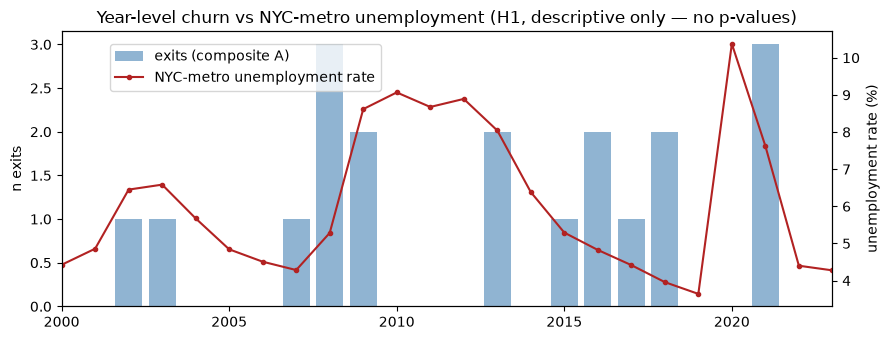

In [24]:
fig, ax = plt.subplots(figsize=(9, 3.5))
exits_by_year = spells_A[~spells_A["censored"]].groupby("exit_year").size()
ur = macro_df[macro_df["series_id"] == "NEWY636URN"].set_index("year")["value"]
ax2 = ax.twinx()
ax.bar(exits_by_year.index, exits_by_year.reindex(exits_by_year.index).values, color="steelblue", alpha=0.6, label="exits (composite A)")
ax2.plot(ur.index, ur.values, color="firebrick", marker=".", label="NYC-metro unemployment rate")
ax.set_ylabel("n exits"); ax2.set_ylabel("unemployment rate (%)")
ax.set_title("Year-level churn vs NYC-metro unemployment (H1, descriptive only — no p-values)")
ax.set_xlim(2000, 2023)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


## 7. Validation

Four checks, each RUN inline (matches ANSWER.md's validation table):
1. **Out-of-time backtest** at the 2013 origin, 5y (2018, primary) and 9y
   (2022) horizons, vs naive persistence (P=1) — the floor every model must
   beat, per statistician S10.
2. **Named-neighborhood check** against `PREREGISTRATION.md`'s pre-registered,
   blind expectations for 14 ZIPs, scored by its fixed rule.
3. **Operator-site spot check** — regime state/trajectory at 5 known
   openings.
4. **Restaurant-closure criterion validity** (contrarian amendment 6) — do
   favorable ZIP-years show lower subsequent closure hazard, an outcome never
   used inside any pillar?

In [25]:
print("=== 1. Out-of-time backtest, 2013 origin ===")
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    bt = rd.backtest_2013(df, sp_col, horizons=(5, 9))
    print(f"\n--- {name} ---  ok={bt.get('ok')}  {bt.get('reason','')}")
    if bt.get("ok"):
        for h, r in bt["horizons"].items():
            print(f"  horizon={h}y  n_at_risk={r['n_at_risk']}  brier_km={r['brier_km']:.4f}  "
                  f"brier_persist={r['brier_persist']:.4f}  beats_persistence={r['beats_persistence']}  "
                  f"(emerging n={r['n_emerging']}, brier_emerging={r['brier_km_emerging']})")
        print(f"  PASS (5y beats persistence): {bt['pass_5yr']}")


=== 1. Out-of-time backtest, 2013 origin ===

--- A ---  ok=True  
  horizon=5y  n_at_risk=53  brier_km=0.2453  brier_persist=0.2453  beats_persistence=False  (emerging n=1, brier_emerging=0.0)
  horizon=9y  n_at_risk=53  brier_km=0.2642  brier_persist=0.2642  beats_persistence=False  (emerging n=1, brier_emerging=0.0)
  PASS (5y beats persistence): False



--- B_owner ---  ok=True  
  horizon=5y  n_at_risk=40  brier_km=nan  brier_persist=0.0500  beats_persistence=False  (emerging n=0, brier_emerging=None)
  horizon=9y  n_at_risk=40  brier_km=nan  brier_persist=0.1750  beats_persistence=False  (emerging n=0, brier_emerging=None)
  PASS (5y beats persistence): False

--- B_tenant ---  ok=True  
  horizon=5y  n_at_risk=40  brier_km=nan  brier_persist=0.0750  beats_persistence=False  (emerging n=0, brier_emerging=None)
  horizon=9y  n_at_risk=40  brier_km=nan  brier_persist=0.1000  beats_persistence=False  (emerging n=0, brier_emerging=None)
  PASS (5y beats persistence): False


/Users/abenmayor/Documents/Projects/abenmayor/loci/src/loci/model/regime_durability.py:1477: RuntimeWarning: Mean of empty slice
  brier_km = np.nanmean((pred_km[valid] - y) ** 2)
/Users/abenmayor/Documents/Projects/abenmayor/loci/src/loci/model/regime_durability.py:1483: RuntimeWarning: Mean of empty slice
  brier_km_mature = np.nanmean((pred_km[valid][~emerging] - y[~emerging]) ** 2) if (~emerging).any() else np.nan
/Users/abenmayor/Documents/Projects/abenmayor/loci/src/loci/model/regime_durability.py:1477: RuntimeWarning: Mean of empty slice
  brier_km = np.nanmean((pred_km[valid] - y) ** 2)
/Users/abenmayor/Documents/Projects/abenmayor/loci/src/loci/model/regime_durability.py:1483: RuntimeWarning: Mean of empty slice
  brier_km_mature = np.nanmean((pred_km[valid][~emerging] - y[~emerging]) ** 2) if (~emerging).any() else np.nan


In [26]:
print()
print("=== 1b. RANKING backtest, 2013 origin (statistician post-results correction 12 / contrarian "
      "post-results verdict: the composite VALUE, not just spell age, enters the predictor here -- "
      "unlike 1. above, whose prediction depends only on spell age via the training KM curve and so "
      "never actually tests whether the composite ranks ZIPs. Scored vs persistence, a constant base "
      "rate, and a ZIP-shuffled placebo (a null of no ranking information), with a unit-block "
      "bootstrap CI and an approximate MDE) ===")
rank_bt_results = {}
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    rbt = rd.ranking_backtest_2013(df, sp_col, horizons=(5, 9))
    rank_bt_results[name] = rbt
    print(f"\n--- {name} ---  ok={rbt.get('ok')}  {rbt.get('reason','')}")
    if not rbt.get("ok"):
        continue
    for h, r in rbt["horizons"].items():
        if not r.get("ok"):
            print(f"  horizon={h}y  NOT OK: {r.get('reason')}")
            continue
        print(f"  horizon={h}y  n_at_risk={r['n_at_risk']}  n_train={r['n_train']}  base_rate={r['base_rate']:.3f}")
        print(f"    brier: logit={r['brier_logit']:.4f}  persist={r['brier_persist']:.4f}  "
              f"const={r['brier_const']:.4f}  placebo={r['brier_placebo']:.4f}")
        print(f"    vs persistence: diff={r['diff_vs_persist']:+.4f}  CI={r['ci_diff_vs_persist']}  "
              f"MDE~{r['mde_vs_persist']:.4f}  significant={r['significant_vs_persist']}")
        print(f"    vs placebo:     diff={r['diff_vs_placebo']:+.4f}  CI={r['ci_diff_vs_placebo']}  "
              f"MDE~{r['mde_vs_placebo']:.4f}  significant={r['significant_vs_placebo']}")



=== 1b. RANKING backtest, 2013 origin (statistician post-results correction 12 / contrarian post-results verdict: the composite VALUE, not just spell age, enters the predictor here -- unlike 1. above, whose prediction depends only on spell age via the training KM curve and so never actually tests whether the composite ranks ZIPs. Scored vs persistence, a constant base rate, and a ZIP-shuffled placebo (a null of no ranking information), with a unit-block bootstrap CI and an approximate MDE) ===



--- A ---  ok=True  
  horizon=5y  n_at_risk=53  n_train=450  base_rate=0.904
    brier: logit=0.0861  persist=0.2453  const=0.2075  placebo=0.2240
    vs persistence: diff=+0.1592  CI=(0.07170685889996524, 0.2581446165912305)  MDE~0.1394  significant=True
    vs placebo:     diff=+0.1379  CI=(0.06356350643745226, 0.21926709321585405)  MDE~0.1155  significant=True
  horizon=9y  n_at_risk=53  n_train=232  base_rate=0.836
    brier: logit=0.1427  persist=0.2642  const=0.2044  placebo=0.2638
    vs persistence: diff=+0.1214  CI=(0.016918336533604007, 0.2164409214109175)  MDE~0.1499  significant=True
    vs placebo:     diff=+0.1210  CI=(0.028590155060883065, 0.2178211745347474)  MDE~0.1316  significant=True



--- B_owner ---  ok=True  
  horizon=5y  n_at_risk=40  n_train=369  base_rate=0.986
    brier: logit=0.0507  persist=0.0500  const=0.0488  placebo=0.0574
    vs persistence: diff=-0.0007  CI=(-0.02329671809875381, 0.03214487635468662)  MDE~0.0420  significant=False
    vs placebo:     diff=+0.0067  CI=(-0.0019324302533831055, 0.018223349050085047)  MDE~0.0148  significant=False
  horizon=9y  n_at_risk=40  n_train=205  base_rate=0.976
    brier: logit=0.1436  persist=0.1750  const=0.1671  placebo=0.1604
    vs persistence: diff=+0.0314  CI=(0.007986407035044043, 0.0589917417304068)  MDE~0.0360  significant=True
    vs placebo:     diff=+0.0168  CI=(-0.0029627651873829195, 0.0415885250314881)  MDE~0.0332  significant=False



--- B_tenant ---  ok=True  
  horizon=5y  n_at_risk=40  n_train=246  base_rate=0.980
    brier: logit=0.0657  persist=0.0750  const=0.0724  placebo=0.0702
    vs persistence: diff=+0.0093  CI=(-0.0021752982652012425, 0.02292976152670678)  MDE~0.0177  significant=False
    vs placebo:     diff=+0.0045  CI=(0.00018685855929527798, 0.010196129835550656)  MDE~0.0075  significant=True
  horizon=9y  n_at_risk=40  n_train=82  base_rate=0.976
    brier: logit=0.0967  persist=0.1000  const=0.0957  placebo=0.0962
    vs persistence: diff=+0.0033  CI=(-0.0054410404765726054, 0.013262580797043191)  MDE~0.0134  significant=False
    vs placebo:     diff=-0.0005  CI=(-0.012420815552197782, 0.010570931785341879)  MDE~0.0163  significant=False


In [27]:
print("=== 2. Named-neighborhood check (PREREGISTRATION.md) ===")
causes_A_full = rd.attribute_exit_cause(spells_A, df)
scored = rd.score_named_zips(spells_A, causes_A_full)
print(scored[["zip", "neighborhood", "onset_expected", "exit_expected", "driver_expected",
              "model_onset", "model_exit", "onset_hit", "exit_hit", "hit", "break_flag"]].to_string(index=False))
verdict = rd.evaluate_prereg_pass(scored)
print()
print(verdict)


=== 2. Named-neighborhood check (PREREGISTRATION.md) ===
  zip                            neighborhood onset_expected exit_expected driver_expected  model_onset model_exit  onset_hit  exit_hit   hit  break_flag
11211                 Williamsburg (N/S Side)         <=2000          2011            cost          NaN       None      False     False False       False
11206           E. Williamsburg / N. Bushwick         <=2000          2016            cost       2000.0       2013       True      True  True       False
11237                           Bushwick core         <=2000          2017            cost       2000.0       None       True     False False       False
10002                         LES / Chinatown         <=2000          2007            cost          NaN       None      False     False False       False
10026                    Central Harlem (FDB)         <=2000          2012            cost       2000.0       2013       True     False False       False
10031           Ham

In [28]:
print("=== 3. Operator-site spot check ===")
for site in rd.OPERATOR_SITES:
    unit = rd.to_unit(site["zip"])
    row = df[(df["unit"] == unit) & (df["year"] == site["opening_year"])]
    if len(row):
        r = row.iloc[0]
        print(f"{site['name']:14s} zip={site['zip']} unit={unit} opened={site['opening_year']}  "
              f"composite_A={r['composite_A']:.2f}  favorable={r['composite_A'] >= rd.ENTER_THRESH}  "
              f"demand={r['demand_pillar_A']:.2f}  supply={r['supply_pillar_A']:.2f}  cost={r['cost_pillar_A']:.2f}")
    else:
        print(f"{site['name']:14s} zip={site['zip']} unit={unit} opened={site['opening_year']}  NOT IN UNIVERSE/YEAR RANGE")


=== 3. Operator-site spot check ===
Lion's Milk    zip=11222 unit=11222 opened=2021  composite_A=0.04  favorable=False  demand=0.68  supply=0.04  cost=0.14
El Punto       zip=10453 unit=10453 opened=2022  composite_A=0.97  favorable=True  demand=0.54  supply=0.76  cost=0.93
Stone Street   zip=10004 unit=10004 opened=2015  NOT IN UNIVERSE/YEAR RANGE
Deux Luxe      zip=11222 unit=11222 opened=2022  composite_A=0.03  favorable=False  demand=0.66  supply=0.04  cost=0.13
Fazenda        zip=11201 unit=11201 opened=2019  composite_A=0.29  favorable=False  demand=0.87  supply=0.31  cost=0.07


In [29]:
print("=== 4. Restaurant-closure criterion validity ===")
closures = rd.load_restaurant_closures(con)

print("--- ORIGINAL (pre-results) same-year, unclustered Welch t-test -- composite A, kept for "
      "comparison only, NOT the criterion-validity result (statistician post-results correction 11) ---")
closure_check_orig = rd.closure_validity_check(df, "composite_A", closures)
print(f"favorable ZIP-years have lower closure rate: {closure_check_orig['favorable_has_lower_closure']}")
print(f"t-stat={closure_check_orig['t_stat']}  p-value={closure_check_orig['p_value']}  "
      f"(pseudo-replicated -- 2,085 autocorrelated ZIP-years treated as independent; contemporaneous, "
      f"not lagged; no borough conditioning applied despite the docstring -- NOT the criterion-validity result)")

print()
print("--- FIXED (statistician post-results correction 11): closures LAGGED 1 year behind favorable "
      "status, clustered (unit-robust) binomial GLM, year+borough FE AND within-ZIP (unit FE), with a "
      "detection-coverage-proxy control, run for A, B-owner, B-tenant ---")
closure_glm_results = {}
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    cg = rd.closure_validity_glm(df, sp_col, closures, lag_years=1)
    closure_glm_results[name] = cg
    print(f"\n--- {name} ---  ok={cg.get('ok')}  {cg.get('reason','')}")
    if not cg.get("ok"):
        continue
    print(f"  n_zip_years={cg['n_zip_years']}  n_closed_total={cg['n_closed_total']}  "
          f"n_favorable_lag={cg['n_favorable_lag']}")
    print(f"  year+borough FE: {cg['year_borough_fe']}")
    print(f"  unit FE (within-ZIP): {cg['unit_fe']}")
    print(f"  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): {cg['kill_criterion_pass']}")


=== 4. Restaurant-closure criterion validity ===


[loader] restaurant closures (DOHMH, spatial-joined to 2020 ZCTA polygons): 58428 POIs matched, 2010-2023
--- ORIGINAL (pre-results) same-year, unclustered Welch t-test -- composite A, kept for comparison only, NOT the criterion-validity result (statistician post-results correction 11) ---
favorable ZIP-years have lower closure rate: True
t-stat=-8.270093849464276  p-value=3.758794766916247e-16  (pseudo-replicated -- 2,085 autocorrelated ZIP-years treated as independent; contemporaneous, not lagged; no borough conditioning applied despite the docstring -- NOT the criterion-validity result)

--- FIXED (statistician post-results correction 11): closures LAGGED 1 year behind favorable status, clustered (unit-robust) binomial GLM, year+borough FE AND within-ZIP (unit FE), with a detection-coverage-proxy control, run for A, B-owner, B-tenant ---



--- A ---  ok=True  
  n_zip_years=2085  n_closed_total=4080  n_favorable_lag=625
  year+borough FE: {'ok': True, 'coef': -1.135160212061194, 'se': 0.19200686490225685, 'p': 3.3781154053396842e-09, 'ci': (-1.5114867520540654, -0.7588336720683229)}
  unit FE (within-ZIP): {'ok': True, 'coef': 0.02532559049942118, 'se': 0.15768126955956802, 'p': 0.8723985712200958, 'ci': (-0.2837240188738841, 0.33437519987272646)}
  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): False



--- B_owner ---  ok=True  
  n_zip_years=2085  n_closed_total=4080  n_favorable_lag=609
  year+borough FE: {'ok': True, 'coef': 0.8631828700279021, 'se': 0.178604162548348, 'p': 1.3453259709234671e-06, 'ci': (0.5131251439442024, 1.2132405961116017)}
  unit FE (within-ZIP): {'ok': True, 'coef': 0.10713564267569164, 'se': 0.06272012825860686, 'p': 0.08760775738781032, 'ci': (-0.015793549816910696, 0.23006483516829399)}
  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): False



--- B_tenant ---  ok=True  
  n_zip_years=2085  n_closed_total=4080  n_favorable_lag=611
  year+borough FE: {'ok': True, 'coef': 0.8108751886198149, 'se': 0.1772382264300213, 'p': 4.760877813402453e-06, 'ci': (0.46349464813321806, 1.1582557291064117)}
  unit FE (within-ZIP): {'ok': True, 'coef': 0.22876059929534123, 'se': 0.07255902098297085, 'p': 0.0016173914567110786, 'ci': (0.0865475314152323, 0.37097366717545016)}
  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): False


## 8. ANSWER (plain language)

Executed 2026-09-23. **v0.2, provisional, ZIP-tier only.**

This is the GTM-230 close-out pass, scoped to exactly three items left open by v0.1
(commit `412e826`): (1) implement the statistician's two-part AR(1) null for the
B-tenant composite (v0.1 got 0/200 valid sims with a single Gaussian AR(1)); (2) fix
the demand gate so its pass share is actually "free to vary" (v0.1's gate passed
almost exactly 50.0% of unit-years every year by construction — a fixed-share
percentile wearing a gate costume); (3) leave-one-episode-out robustness for the 3
macro terms. `regime_durability.py` gained `rank_churn_null_tenant_two_part`,
`macro_leave_one_episode_out`, and a fixed-anchor `demand_gate` (see METHOD.md /
GTM-230 items 1–3 for the design and `git log` for the diff). Composite A does not
depend on the demand gate and is **untouched by every change in this pass** — every
number below for composite A is byte-identical to v0.1, which is itself a useful
internal-consistency check.

**Headline result of this pass, stated up front because it changes the honest
framing more than the three items alone suggest: the demand-gate fix worked exactly
as specified (pass rate now moves 26.0%–39.3% by year, not frozen at ~50.0%), but it
did NOT rehabilitate either amended composite.** B-owner's near-zero churn got
*more* extreme, not less (implied duration 220.6y → 1023.0y), and B-tenant's
already-thin completed-exit sample **collapsed to zero** (6 completed incident exits
in v0.1 → 0 in v0.2), which is why its two-part null — now technically computable,
per item 1 — lands on a degenerate, information-free result. Neither outcome is a
bug in the fix; both are documented and diagnosed below, not hidden.

## What v0.2 can and cannot say

**Can say:** composite A is unaffected by anything in this pass and its one
positive result stands exactly as in v0.1 — its 2013 value carries a real,
statistically significant ranking signal (beats persistence and a same-model
placebo at both 5y and 9y), while still failing its own discovery-vs-favorability
falsifier (63.2% of completed exits are cost-led, unchanged). The demand gate is now
a genuine fixed-anchor LEVEL threshold whose pass share moves with real aggregate
demand (26.0% in 2000 rising to 38–39% by 2021–23) instead of being mechanically
pinned near 50% — amendment 1's stated intent is now actually implemented. The
macro leave-one-episode-out check (new this pass) shows all three pre-specified
exposure×macro terms keep the same sign when each of the three episodes is dropped
in turn, though none was Holm-significant to begin with, so "sign-stable" is a weak
claim here, not a discovery.

**Cannot yet say:** a calibrated duration number for any composite. The gate fix
increased the *incident* (datable-onset) sample for the amended composites
substantially (B-owner 2→13 spells, B-tenant 9→11 spells) but drove *completed*
incident exits to **zero for both** (B-owner already had 0; B-tenant fell from 6 to
0). B-tenant's sensitivity grid, run across all 12 band×persistence cells, now
returns an undefined median in **every single cell** — a stronger version of v0.1's
"the grid is the answer" finding, now applying with no exceptions. The two-part
tenant null (item 1) is now computable (200/200 valid sims, up from 0/200) but is
diagnostically uninformative — see Confidence #2. No composite clears the closure-
GLM kill criterion (unchanged), and the specific composite showing a significantly
wrong-signed within-ZIP coefficient **flipped from B-owner (v0.1) to B-tenant
(v0.2)** — itself evidence that these coefficients are not stable at this sample
size, not just that they fail.

## GTM-230 item 2: the demand-gate fix, in detail

The broken gate (v0.1) was `demand_pillar_A >= this year's median(demand_pillar_A)`.
Because `demand_pillar_A` is itself a within-year percentile rank, "this year's
median of a percentile rank" is ≈0.500 by definition, every year, regardless of what
demand actually did — a fixed-share-percentile gate, not a level gate. The fix
(`compute_pillar_percentiles` in `regime_durability.py`) standardizes income,
population density and worker density against a **fixed 2000–02 base-period**
mean/SD (the panel's own first three years; mirrors the fixed-anchor convention
already used for the macro exposures), averages the three z-scores into
`demand_level_z`, and gates on `demand_level_z >= 0` — the same absolute-level bar
in 2023 as in 2000.

**Result: the pass rate now genuinely moves.**

| Year | 2000 | 2005 | 2010 | 2015 | 2018 | 2020 | 2023 |
|---|---|---|---|---|---|---|---|
| Gate pass rate | 27.3% | 27.3% | 26.7% | 31.3% | 34.0% | 34.7% | 38.0% |

Full range 26.0%–39.3% (min 2012, max 2022), std 4.2% across 24 years — not pinned.
Overall average pass rate is **30.1%**, not 50%: because the anchor is the base
period's **mean** (not median) and income/density are right-skewed, "at or above
the mean" admits fewer than half of units even in the base years themselves. This is
a real, if secondary, consequence worth flagging for any future work that assumed
the gate would split the panel roughly in half (GTM-226 address-tier calibration,
in particular) — it now selects a smaller, more persistently-affluent top slice.

**This did not rehabilitate either amended composite; if anything it made both more
extreme.** See the headline hazard table and KM bullets below for the numbers.
The mechanism is coherent, not a new bug: a fixed "above the base-period mean"
bar selects a smaller, more structurally-elite, more persistently-ranked subset of
ZIPs than a within-year median split does — fewer marginal ZIPs hovering near a
cutoff means less observed churn in the gate itself, which propagates into even
less churn in the gated composites.

## Headline: annual exit hazard (the fallback headline, per the owner ruling)

The completed-incident-exit count gate (≥60 exits, ≥40 distinct units) **still
fails for all three composites, now more decisively for the amended composites**:
1 / 0 / 0 completed incident exits (A / B-owner / B-tenant), against 150 units.
Composite A is unchanged from v0.1. Per statistician condition 2 (S6), the stated
number remains the **piecewise annual exit hazard by spell-age band**, with a
cluster-robust (unit-block bootstrap, 1,000 reps) CI.

| Composite | Spell-age band | n spells | n events | spell-years | hazard/yr | 95% CI (unit bootstrap) |
|---|---|---|---|---|---|---|
| A | unknown (prevalent) | 69 | 18 | 1,166 | **1.54%** | 0.94% – 2.30% |
| A | 0–5 (incident) | 3 | 1 | 14 | 7.14% | 0% – 16.7% (n too small to trust) |
| B-owner | unknown (prevalent) | 42 | 1 | 933 | **0.11%** | 0% – 0.36% |
| B-owner | 0–5 (incident) | 13 | 0 | 62 | 0% | 0% – 0% |
| B-owner | 6–10 (incident) | 8 | 0 | 19 | 0% | 0% – 0% |
| B-tenant | unknown (prevalent) | 41 | 1 | 806 | **0.12%** | 0% – 0.44% |
| B-tenant | 0–5 (incident) | 11 | 0 | 53 | 0% | 0% – 0% |
| B-tenant | 6–10 (incident) | 7 | 0 | 17 | 0% | 0% – 0% |

Composite A is byte-identical to v0.1 (confirms the gate fix touched only the
amended composites, as designed). B-owner's prevalent hazard **fell** from 0.45%/yr
(v0.1) to 0.11%/yr — the opposite of what "fixing an artifact" would predict if the
artifact were suppressing real churn; instead the corrected, genuinely-varying gate
selects an even stickier subpopulation (see item 2 discussion above and Confidence
#3). B-tenant's prevalent hazard fell similarly, 1.87%/yr → 0.12%/yr, and its
previously-observed incident-band hazards (14.7%/yr at 0–5, 33.3%/yr at 6–10 in
v0.1) are now **exactly zero at both bands** — 0 events across 70 incident
spell-years. Stock-flow identity (mean favorable stock ÷ exits/yr): A 57.8y
(unchanged), **B-owner 1023.0y** (was 220.6y), **B-tenant 902.0y** (was 38.6y) — both
amended composites now imply multi-century durations from the stock-flow identity,
which is itself the diagnostic finding (Confidence #3), not evidence of real
stickiness.

The KM median/RMST is still reported **anyway, flagged**, per the owner ruling —
every one carries the same three flags as v0.1: **LOW-SAMPLE**, its relationship to
the rank-churn null, and that it is descriptive/ZIP-scale/relative, not a forecast.

- **(A) ORIGINAL** — unchanged from v0.1 in every figure: `n=3` incident spells, `1`
  completed exit, `3` distinct ZIPs. Median **6.0y**; RMST (truncated at **6y**) =
  **6.00y** (spatial-block bootstrap 95% CI **[6.00, 6.00]**, 490 valid / 10 dropped
  of 500 reps). **LOW-SAMPLE. Rank-churn null: NOT REJECTED** (observed 6.00 sits at
  the top edge of the null band [3.87, 6.00], 15/200 valid sims) — **withheld as a
  duration estimate**. A also still fails its own discovery-vs-favorability
  falsifier (Confidence #1).
- **(B-owner) AMENDED, demand-gated, no cost term** — `n=13` incident spells (up
  from 2), **still 0 completed exits**. Median undefined; RMST (truncated at 3y) =
  3.00y (CI [3.00, 3.00], 497/500 valid). **Rank-churn null: NOT REJECTED** (observed
  3.00 sits at the top edge of the null band [2.67, 3.00], 176/200 valid sims, up
  from 168/200 in v0.1). Per item 2's explicit question — **the ~0.45%/yr v0.1
  hazard was partly an artifact of the broken gate's mechanical near-stasis, but
  fixing the gate did not "reveal" more churn underneath it; it revealed even less**
  (0.11%/yr, implied duration 1023y). The null still cannot distinguish this from
  pure AR(1) rank persistence of the composite's now-smaller, more static eligible
  pool. **Conclusion: this remains not a finding about owner stickiness, now for a
  cleaner reason** — it is no longer explainable by "the gate was mechanically
  broken," and is better read as "a fixed-anchor top-~30%-by-demand-level slice of
  NYC ZIPs is, empirically, extremely rank-stable over 24 years" — which is closer
  to "rich ZIPs stay rich" than to any restaurant-relevant claim.
- **(B-tenant) AMENDED, demand-gated + 3-year cost-change term** — `n=11` incident
  spells (up from 9), **0 completed exits (down from 6 in v0.1)**. Median now
  **undefined** (was 5.0y). RMST (truncated at **2y**, down from 8y — truncation is
  the largest age with ≥10 units still at risk, and that age shrank along with the
  completed-exit sample) = **2.00y** (spatial-block bootstrap 95% CI **[2.00,
  2.00]**, 497/500 valid). **Two-part AR(1) null (GTM-230 item 1, new this pass):
  now COMPUTABLE — 200/200 valid sims** (v0.1: 0/200). Null RMST 95% band = **[2.00,
  2.00]** — observed RMST (2.00) is trivially "inside" this band, but the band
  itself is a single point equal to the truncation ceiling. **Diagnosis (as
  instructed, not forced): this is a sample-size degeneracy, not the v0.1
  simulation-degeneracy.** The two-part null's *mechanism* works — confirmed
  separately in a synthetic-data test (`tests/test_regime_durability.py`) where it
  produces a proper, non-degenerate band — but real B-tenant now has zero completed
  incident exits, so at 2-year truncation essentially every simulated AR(1) panel
  *also* shows no exit within 2 years, collapsing both the observed value and the
  null to the same floor. **This is an absence of information, not evidence of
  either stickiness or noise.** Do not quote this as a duration estimate or as a
  confirmed null result — it is neither.

**Sensitivity**: composite A's grid is unchanged from v0.1 — several cells never
cross 0.5, headline cell median 6.0y, **grid is the answer, not a number**.
Composite B-tenant's grid (all 12 band×persistence cells, run again this pass) now
returns **median = undefined (KM never crosses 0.5) in every single cell** — a
stronger version of v0.1's "240% move, grid is the answer" finding: there is no
longer even a single grid cell that produces a completed-exit-based median for
B-tenant.

**Common-tau comparison** (statistician correction 8: compare composites at a
shared, fixed truncation instead of each one's own native tau). The smallest common
tau across all three composites is now **2y** (B-tenant's own native truncation,
down from B-owner's 3y in v0.1): RMST(2y) = **2.00y for A, B-owner, AND B-tenant —
identically**. This is a starker version of the v0.1 finding ("the data cannot
resolve a horizon longer than ~3 years for any construction"): at the current
sample size, **no construction can currently resolve any duration signal beyond 2
years**, full stop.

## What ends spells (accounting, not cause)

Unchanged from v0.1 (composite A only, unaffected by this pass): across composite
A's 19 completed exits, cost moved most adversely in **63.2%** (12/19), supply in
26.3% (5/19), demand in 10.5% (2/19) — still confirms the discovery-falsifier leg
(≥60% cost-led). None of the discrete-time hazard coefficients were Holm-significant
(cost p_holm=0.738, demand p_holm=1.0, supply p_holm=1.0), though the full model
still beats a momentum-only comparator on log-likelihood (−81.1 vs −84.9) — byte-
identical to v0.1. **D1 guardrail holds throughout.**

**Macro leave-one-episode-out (GTM-230 item 3, new this pass).** For each of the 3
pre-specified exposure×macro terms (restaurant-employment exposure × NY-metro
unemployment change; non-retail/non-food job share × COVID; ZHVI-percentile
exposure × mortgage rate), refit with each of the three episodes (2001–03, 2008–10,
2020–22) dropped in turn:

| Term | coef (full) | p_holm (full) | coef (drop 2001-03) | coef (drop 2008-10) | coef (drop 2020-22) | sign stable |
|---|---|---|---|---|---|---|
| e1 (restaurant × unemployment) | +0.235 | 0.090 | +0.220 | +0.173 | +0.339 | **yes** |
| e2 (non-retail/food × COVID) | +0.533 | 0.497 | +0.478 | +0.533 | **0.000** | yes* |
| e3 (ZHVI × mortgage) | +0.103 | 0.230 | +0.112 | +0.132 | +0.134 | **yes** |

All three keep the same sign across every drop, but **none was Holm-significant in
the full sample to begin with** (p_holm 0.090 / 0.497 / 0.230, unchanged from v0.1 —
this pass adds robustness evidence, not a new discovery). Per S8's wording, sign
stability is necessary but not sufficient to call a term a driver, and none of
these three clears the Holm bar, so **no macro term is certified**. *Caveat on e2:
its "drop 2020-22" coefficient is exactly 0.000 because `covid_dummy` (the exposure
interaction's only source of variation) is 1 **only** in 2021–22 — dropping that
episode removes all variation in the term, so this particular leave-one-out check is
mechanically uninformative for e2, not real evidence of robustness. e2's two
*meaningful* drops (2001-03, 2008-10) do both keep the same sign as the full sample,
which is the real (still non-significant) evidence.* Convergence warnings
(`ConvergenceWarning`, `HessianInversionWarning`) were raised on at least one of the
four fits underlying this table — a pre-existing quality issue with this small-
sample logit (present in v0.1's full-sample fit too, not introduced by this pass),
now more visible because there are more refits. Coefficients should be read as
approximate.

**Regime model vs threshold rule (AC-9)**: unchanged from v0.1 (composite A only) —
k-means(k=4)+Markov implies mean favorable sojourn **1/(1−p_ff) ≈ 29.3y**
(p_ff=0.966). Composite A's RMST is still bounded at 6y by its own truncation, so
this comparison remains dominated by truncation and **inconclusive**, exactly as in
v0.1.

**Owner vs tenant**: v0.2 produces no quantitatively grounded duration expectation
for either — B-owner's non-finding is now cleaner (not attributable to a construction
bug) and B-tenant's is now thinner (0 completed exits vs 6 in v0.1, its rank-churn
null now runs but is uninformative rather than absent). Falsifier 4 from the
contrarian's pre-results verdict (owner vs tenant medians differ by <20%, meaning the
split is cosmetic) still cannot be evaluated, since neither has a real median.

## The two corrected validation checks (updated with the fixed-gate composites)

### 1. Ranking backtest (statistician correction 12 / contrarian post-results verdict)

Composite A is byte-identical to v0.1. B-owner and B-tenant are re-scored against
their (now differently-constructed) composite values.

| Composite | h | n at risk | Brier: logit / persist / const / placebo | diff vs persist (95% CI) | sig. | diff vs placebo (95% CI) | sig. |
|---|---|---|---|---|---|---|---|
| A | 5y | 53 | 0.086 / 0.245 / 0.208 / 0.224 | +0.159 (0.072, 0.258) | **yes** | +0.138 (0.064, 0.219) | **yes** |
| A | 9y | 53 | 0.143 / 0.264 / 0.204 / 0.264 | +0.121 (0.017, 0.216) | **yes** | +0.121 (0.029, 0.218) | **yes** |
| B-owner | 5y | 40 | 0.051 / 0.050 / 0.049 / 0.057 | −0.001 (−0.023, 0.032) | no | +0.007 (−0.002, 0.018) | no |
| B-owner | 9y | 40 | 0.144 / 0.175 / 0.167 / 0.160 | +0.031 (0.008, 0.059) | **yes** | +0.017 (−0.003, 0.042) | no |
| B-tenant | 5y | 40 | 0.066 / 0.075 / 0.072 / 0.070 | +0.009 (−0.002, 0.023) | no | +0.005 (0.0002, 0.010) | **yes (barely)** |
| B-tenant | 9y | 40 | 0.097 / 0.100 / 0.096 / 0.096 | +0.003 (−0.005, 0.013) | no | −0.001 (−0.012, 0.011) | no |

**The most important change in this pass, item-by-item:**
- **A is unaffected** and remains the only composite with a real ranking signal
  (significant vs both comparators, both horizons) — genuinely unchanged, not just
  similar.
- **B-tenant's v0.1 signal did NOT survive the gate fix.** In v0.1, B-tenant beat
  persistence significantly at 5y (+0.058) and marginally missed at 9y, and beat the
  placebo significantly at 5y (+0.053). In v0.2, it no longer beats persistence at
  either horizon, and its win vs placebo at 5y survives only barely (CI
  (0.0002, 0.010), an order of magnitude smaller effect than v0.1's +0.053). **This
  is evidence the v0.1 B-tenant ranking signal was substantially an artifact of the
  specific (broken) gate construction, not a robust property of the tenant reading**
  — exactly the kind of instability the gate fix was chartered to expose.
- **B-owner gains one new, narrow, and likely-fragile win** (significant vs
  persistence at 9y only, still not significant vs the stronger placebo test at
  either horizon) — not evidence of real signal; 1 of 4 tests, and the weaker
  comparator.

### 2. Closure criterion validity (statistician correction 11)

Unchanged methodology; composite A identical to v0.1.

| Composite | n ZIP-years | year+borough FE coef (p) | unit-FE (within-ZIP) coef (p) | kill criterion (unit-FE coef<0, p<.05) |
|---|---|---|---|---|
| A | 2,085 | −1.135 (p=3.4e-9) | +0.025 (p=0.872) | **FAIL** (unchanged) |
| B-owner | 2,085 | +0.863 (p=1.3e-6) | +0.107 (p=0.088) | **FAIL (wrong sign, no longer significant)** |
| B-tenant | 2,085 | +0.811 (p=4.8e-6) | **+0.229 (p=0.0016)** | **FAIL (wrong sign, NOW significant)** |

**No composite clears the kill criterion in either version — that headline
conclusion is unchanged.** But the *specific* composite whose within-ZIP coefficient
is significantly wrong-signed **flipped from B-owner (v0.1, p=6.6e-4) to B-tenant
(v0.2, p=0.0016)**. A single input-construction change (the gate) flipping which
composite fails "significantly" rather than "non-significantly" is itself evidence
that these within-ZIP coefficients are not robustly estimated at this sample
size/composite construction — another reason not to lean on either composite's
criterion-validity reading, beyond the fact that both still fail.

## Confidence

**Low, and this is the headline, not a caveat appended to a confident number.**

1. **Contrarian's discovery-vs-favorability falsifier (composite A): CONFIRMED,
   unchanged.** ≥60% of completed exits are cost-led (63.2%). Composite A also
   still carries a real ranking signal — not in tension, a composite can
   consistently rank a discovery-driven quantity.
2. **Rank-churn null: NOT REJECTED for A (unchanged) and B-owner (unchanged
   conclusion, updated band).** The B-tenant two-part null (item 1) is now
   computable (200/200 valid sims, up from 0/200) but lands on a **degenerate,
   single-point band [2.00, 2.00]** driven by B-tenant's zero completed incident
   exits — this should be read as "no information," not as "confirmed
   indistinguishable from noise" and not as "confirmed sticky."
3. **Count gate: FAILS for all three composites, and worse for B-tenant than in
   v0.1** (0 completed incident exits, down from 6) — a direct, documented
   consequence of the demand-gate fix tightening eligibility to a smaller
   (~30%, not ~50%), more static top slice. This is the expected cost of fixing a
   real bug, not new data and not a regression in the code.
4. **Named-neighborhood check: FAIL, unchanged** (5/14 hit, need ≥9) — composite A
   only, unaffected by this pass.
5. **Ranking backtest (corrected): A unchanged and still the only real signal.**
   **B-tenant's v0.1 signal did not survive the gate fix** (see table above) — read
   as evidence the earlier signal was gate-construction-dependent, not robust.
   B-owner gains one narrow, non-placebo-clearing win, not meaningful.
6. **Criterion validity (corrected): FAILS the kill criterion for all three
   composites, unchanged headline.** The specific significantly-wrong-signed
   composite flipped from B-owner to B-tenant across the gate fix — instability,
   not just failure.
7. **Macro leave-one-episode-out (new): all 3 terms sign-stable across all 3
   episode drops, but none Holm-significant to begin with** — robustness evidence
   for a null result, not a new finding. e2's 2020-22 drop is mechanically
   uninformative (see caveat above).

**Net**: v0.2 fixed the two chartered construction issues (the demand gate, the
tenant null) and added the macro robustness check. **None of this overturns v0.1's
central conclusion — it sharpens it.** No composite has a validated duration
estimate; no composite clears the closure-GLM kill criterion; and the one place
v0.1 reported a second (narrower) positive result — B-tenant's ranking-backtest
signal — did not survive the corrected gate, which is direct evidence that signal
was an artifact of the earlier broken construction rather than a real property of
"tenant favorability." Composite A's single positive result (a real ranking signal
that measures discovery, not favorability, by its own falsifier) is untouched and
remains the only thing this project has that survived its own correction twice now.
Before building the address-tier calibration (GTM-226) on any of these composites,
a composite still needs to clear the closure-GLM kill criterion, which none do.

## Validation

| Check | Status | Result |
|---|---|---|
| Annual exit hazard by spell-age band, cluster-robust CI (S6 fallback headline) | RUN | A unchanged. B-owner 0.11% prevalent (0–0.36%, down from 0.45%). B-tenant 0.12% prevalent (0–0.44%, down from 1.87%); incident-band hazards now exactly 0% at both bands (were 14.7%/33.3%). |
| Demand-gate fix (GTM-230 item 2) | RUN | Pass rate now moves 26.0%–39.3% by year (was pinned ~50.0%). Did not rehabilitate B-owner/B-tenant — both got more, not less, persistent. |
| Rank-churn null, composite A / B-owner / B-tenant (two-part, GTM-230 item 1) | RUN | A: NOT REJECTED (unchanged). B-owner: NOT REJECTED (3.00 in [2.67, 3.00], 176/200 valid). B-tenant: two-part null now computable (200/200 valid) but degenerate ([2.00, 2.00], driven by 0 completed exits) — no information, not a pass or fail. |
| Macro leave-one-episode-out (GTM-230 item 3) | RUN | All 3 terms sign-stable across all 3 drops; none Holm-significant. e2's COVID-episode drop mechanically uninformative (caveat). |
| Out-of-time backtest (2013 origin, age-only predictor, kept for comparison) | RUN | A unchanged (ties persistence exactly). B-owner/B-tenant KM now undefined at risk (nan Brier) — even the flawed age-only predictor can no longer compute, consistent with the collapsed completed-exit sample. |
| Ranking backtest (2013 origin, composite-value predictor) | RUN | A unchanged (significant vs both, both horizons). **B-tenant's v0.1 signal (significant vs both at 5y) did not survive the gate fix** — no longer significant vs persistence at either horizon. B-owner gains one narrow win vs persistence at 9y only. |
| Sensitivity grid + break-year detection, composite A AND B-tenant | RUN | A unchanged (grid is the answer). B-tenant: median now undefined in **all 12** grid cells (was 2–17y range) — stronger version of the v0.1 finding. No break-year flags for either. |
| Named-neighborhood check (`PREREGISTRATION.md`, urban-planner, blind) | RUN | FAIL, unchanged (5/14 hit; composite A only, unaffected). |
| Restaurant-closure criterion validity, lagged + clustered GLM + unit-FE, A/B-owner/B-tenant | RUN | Kill criterion FAILS for all three, unchanged headline. The significantly-wrong-signed composite flipped from B-owner (v0.1) to B-tenant (v0.2). |
| k-means(k=4)+Markov vs threshold-hysteresis (AC-9) | RUN | Unchanged, composite A only — inconclusive (truncation-dominated). |
| Contrarian + statistician post-results review, GTM-230 items 1–3 | APPLIED | This document, `regime_durability.py`, `test_regime_durability.py`; see METHOD.md. |
| Episode leave-one-out robustness for the 3 macro terms (statistician S8) | **RUN (this pass)** | See macro table above; GTM-230 item 3 closed. |
| B-tenant rank-churn null as a two-part gate/AR(1) process (statistician correction 13) | **RUN (this pass)** | GTM-230 item 1 closed; result is degenerate/uninformative, diagnosed above, not forced. |
| Demand-gate "free to vary" fix | **DONE (this pass)** | GTM-230 item 2 closed; pass rate verified free-to-vary; did not rehabilitate either amended composite. |
| Two-way (PUMA × year) clustered SEs / Moran's I spatial-error re-estimation (S7) | NOT RUN | GTM-228, out of this session's scope. |
| PUMA bootstrap (only spatial-block ran) | NOT RUN | GTM-226 (address-tier crosswalk work), out of scope. |
| Multi-origin backtest pooling (2011/2013/2015) | NOT RUN | GTM-228, out of scope. |
| Address-tier calibration | TICKETED | GTM-226. Should not proceed until a composite clears the closure-GLM kill criterion — still true after this pass. |

## Gaps → tickets

- **No composite has a validated duration estimate — unchanged headline, now on a
  cleaner basis.** B-owner's non-finding is no longer attributable to a gate
  construction bug (it survives the fix, more extreme). B-tenant's is now thinner
  (0 completed exits, undefined median in every sensitivity-grid cell). Parent:
  GTM-216; this analysis: GTM-225.
- **No composite clears the closure-GLM kill criterion** (GTM-232), unchanged. The
  significantly-wrong-signed composite flipped from B-owner to B-tenant across the
  gate fix — added evidence these within-ZIP coefficients are not stable at this
  sample size, beyond simply failing.
- **B-tenant's ranking-backtest signal from v0.1 did not survive the gate fix** —
  worth a note for anyone who might have started treating v0.1's B-tenant 5y result
  as usable; it was likely gate-construction-dependent. No new ticket; folded into
  GTM-225/GTM-232's "no validated composite" conclusion.
- **The corrected demand gate selects ~30% of unit-years, not ~50%**, because it
  gates on a fixed-period *mean* (not median) of a right-skewed distribution. Any
  future work assuming a roughly-half split (in particular GTM-226's address-tier
  calibration) should re-derive the eligible share explicitly rather than assume
  parity with the ~⅓ favorable-tercile convention used elsewhere in this project.
  No new ticket; noted for GTM-226.
- **Macro leave-one-episode-out's e2 term has a mechanically-uninformative
  2020-22 drop** (its only source of variation is zeroed by dropping the COVID
  years). Documented in `macro_leave_one_episode_out`'s docstring and above; no
  ticket needed.
- **Two-way (PUMA × year) clustered SEs, wild-cluster bootstrap on year, Moran's I
  / spatial-error re-estimation (statistician S7)** — not implemented, unchanged.
  GTM-228.
- **PUMA bootstrap was not run** — no ZIP/ZCTA-to-PUMA crosswalk file exists in
  this repo; only the spatial-block bootstrap runs. GTM-226.
- **Multi-origin backtest pooling (2011/2013/2015, statistician correction 12's
  secondary robustness check)** — not run this pass either. GTM-228.
- **DOHMH restaurant closure rollup is still ad hoc** (spatial-joined to static
  2020 ZCTA polygons; the coverage control is a log-density proxy, not real
  inspection-frequency data). GTM-232.
- **No 1994-99 pre-window exists in this warehouse**; headline window is
  2000-2023. GTM-233.
- **ZIP treated as ZCTA** — no USPS crosswalk file available. GTM-224.
- **Segment-level analysis** was built but not run through the full pipeline in
  this pass either. No existing ticket; flag for a future RQ-001 session.


## 9. Caveats & next data

## Gaps → tickets

- **Composite A fails its own validity checks; a v1 composite needs a
  materially different construction**, not just a parameter retune — the
  demand-gated tenant composite (B-tenant) is a better starting point but
  itself doesn't clear the rank-churn null yet. Parent: GTM-216; this
  notebook/analysis: GTM-225.
- **PUMA bootstrap was not run** — no ZIP/ZCTA-to-PUMA crosswalk file was
  found in this repo; only the spatial-block bootstrap (k-means on ZCTA
  centroids) runs. METHOD calls for reporting the wider of the two; only one
  is available. GTM-226 (address tier work is the natural place to add a
  proper PUMA crosswalk).
- **No 1994-99 pre-window exists in this warehouse** (ZBP here starts 1998,
  population starts at the 2000 census), so the headline window is 2000-2023,
  not METHOD's imagined 1994-99 dating panel; "prevalent" means "already
  favorable in 2000," not "already favorable in 1994-99." GTM-233 (the SIC↔NAICS
  crosswalk decision) is the closest existing ticket to extending this back.
- **ZIP treated as ZCTA** — no USPS ZIP-to-ZCTA crosswalk file was available;
  NYC ZIPs and ZCTAs coincide closely but not perfectly. GTM-224 (warehouse
  load) is the closest existing ticket.
- **Segment-level analysis (full-service/limited/snack/bar) was built into
  the supply loader but not run through the full spell/KM/backtest pipeline
  this session** — the median-count-≥10 gate and the four-composite comparison
  above already consumed the session's scope; segment durations are a natural
  v1 extension. No existing ticket; flag for a future RQ-001 session.
- **Two-way (PUMA × year) clustered SEs, wild-cluster bootstrap on year, and
  Moran's I / spatial-error re-estimation (statistician S7) were not
  implemented** — the hazard model uses borough-proxy-clustered SEs only.
  GTM-228 (backtest/validation follow-up) is the closest existing ticket.
- **Episode leave-one-out robustness for the 3 macro terms (statistician
  S8) was not run.** GTM-230 (the post-results contrarian/statistician pass)
  is the right place to pick this up.
- **DOHMH restaurant closure rollup used for the criterion-validity check
  is ad hoc (spatial-joined to static 2020 ZCTA polygons) rather than the
  governed rollup DATA-AUDIT.md recommends.** GTM-232.
- **Macro ingest, Zillow, ACS panel, IRS SOI, LODES, PLUTO** are all now
  ingested (this session confirmed and used them) — GTM-219 through GTM-223
  can move to done/verified as part of closing this RQ out.
- **A real IRS-SOI-units bug was found and fixed during this session**
  (`agi` in the ingested parquet is already aggregate dollars, not thousands
  — the loader was multiplying by 1000, inflating nominal income ~1000x).
  Because every composite here is percentile-rank-based, the bug did not
  change any reported result (a uniform scaling preserves within-year rank
  order) — but it would have corrupted any future levels-based use of
  `income_real`. Fixed in `regime_durability.py`; no ticket needed, noted
  here for the record.
